# Implement folder Planck equation
Work on epsilon_v

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fp_density_time_series_kD(
    # ── bio params ──
    p_let=0.15, p_aa=0.10, p_sil=0.75,
    mu_M=0.3, sigma_M=0.3,
    get_C=None, eps_Ag=0.0,
    N_i=2500, N_max=2500,
    mu_i=3.0, sigma_i=1.5,
    p_diff=0.10,
    # ── grid / time ──
    eps_min=-7.0, eps_max=7.0, d_eps=0.1,
    T=60.0, dt=0.001, k=2,
    # ── output ──
    snapshot_interval=1.0,
    verbose=False,
):
    # ---------- constants ------------------------------------------------
    f_aa  = p_aa / (p_aa + p_sil)
    f_sil = 1.0 - f_aa
    v     = f_aa * mu_M
    D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
    # juste après avoir calculé D
    dt_max = d_eps**2 / (2 * k * D)       # CFL diffusion
    if dt > dt_max:
        print(
            f"dt = {dt:.3g} dépasse la limite de stabilité {dt_max:.3g} "
            f"pour D={D:.3g}, k={k}, d_eps={d_eps}"
    )

    lam   = np.log(2) + np.log1p(-p_let) + np.log1p(-p_diff)

    # ---------- mesh -----------------------------------------------------
    eps_axis = np.arange(eps_min, eps_max + d_eps, d_eps)
    eps_axes = (eps_axis,) * k
    eps_mesh = np.meshgrid(*eps_axes, indexing="ij")  # list length k

    dV         = d_eps ** k
    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))

    # ---------- initial density -----------------------------------------
    g1d = np.exp(-(eps_axis - mu_i) ** 2 / (2 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * k), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dV)

    # ---------- time-independent P_Ag field ------------------------------
    # exp_sum_axes = C * sum(np.exp(-e) for e in eps_mesh)     # Σ C e^{-ε_v}
    # P_Ag = exp_sum_axes / (exp_sum_axes + np.exp(-eps_Ag))

    # ------------------------------------------------------------------



    snapshots, times = [rho.copy()], [0.0]

    # --------------------------------------------------------------------
    for step in range(1, n_steps + 1):

        N        = rho.sum() * dV
  
        t_now = step * dt
        C_vec = np.array([get_C(t_now, v) for v in range(k)], dtype=float)

        # ---------------------------------------------------------------
        # 2)  ---  PROBABILITÉ d’AIDE T (version "agrégée") ---
        #     exp_sum = Σ_v C_v(t) · e^{-ε_v}
        exp_sum = sum(C_vec[v] * np.exp(-eps_mesh[v]) for v in range(k))

        #     moyenne globale  ⟨e^{-ε̄}⟩  (toutes dimensions confondues)
        mean_exp_neg_eps_all = (rho * np.exp(-sum(eps_mesh))).sum() * dV / N

        PT = exp_sum / (exp_sum + mean_exp_neg_eps_all)


        # # 1) concentrations dynamiques C_v(t)
        # C_vec = np.array([get_C(t_now, v) for v in range(k)], dtype=float)
        # C_tot = C_vec.sum()

        # # 2) moyennes populationnelles   ⟨e^{-ε_v}⟩_pop
        # mean_exp_neg_eps = np.empty(k)
        # for v in range(k):
        #     mean_exp_neg_eps[v] = (rho * np.exp(-eps_mesh[v])).sum() * dV / N

        # # 3) probabilité d’aide T (définition moléculaire)
        # PT = np.zeros_like(rho)
        # for v in range(k):
        #     numer = C_vec[v] * np.exp(-eps_mesh[v])          # C_v e^{-ε_v}
        #     denom = numer + mean_exp_neg_eps[v]              # C_v e^{-ε_v} + ⟨e^{-ε_v}⟩
        #     P_v   = numer / denom
        #     PT   += (C_vec[v] / C_tot) * P_v                 # (C_v / C_tot) · P_v

        # ----------------------------------------------------------------
        # 4) probabilité d’accès antigène  P_Ag  (même C_vec)
        exp_sum_axes = sum(C_vec[v] * np.exp(-eps_mesh[v]) for v in range(k))
        P_Ag = exp_sum_axes / (exp_sum_axes + np.exp(-eps_Ag))



        log_sel = np.log(P_Ag) + np.log(PT)
        avg_log = (rho * log_sel).sum() * dV / N

        Omega = 0.0 if N < N_max else max(0.0, lam + avg_log)
        Gamma = lam + log_sel - Omega

        # ---------- divergence of total flux ----------------------------
# --- flux divergence : version corrigée et testée -----------------
        div_total = np.zeros_like(rho)

        for ax in range(k):
            ρ_fwd  = np.roll(rho, -1, axis=ax)

            adv_full  = v * (rho if v >= 0 else ρ_fwd)
            diff_full = -0.5 * D * (ρ_fwd - rho) / d_eps
            J_internal = adv_full + diff_full               # shape (m,…,m)

            slc = [slice(None)] * k
            slc[ax] = slice(0, -1)                          # m-1 faces internes
            J_internal = J_internal[tuple(slc)]             # shape (m-1,…,m)

            # tableau de faces, même nbre d’axes que ρ
            J_shape = list(rho.shape)
            J_shape[ax] += 1                                # (m+1) faces
            J = np.zeros(J_shape)

            # ---------- correction ici ----------
            idx = [slice(None)] * k        # longueur = k, pas k+1
            idx[ax] = slice(1, -1)         # faces 1…m-1
            J[tuple(idx)] = J_internal
            # ------------------------------------

            div_total += np.diff(J, axis=ax) / d_eps


        # ---------- update ----------------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)              # ensure positivity

        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(step * dt)

        if verbose and step%10==0:
            mean_Gamma = (rho * Gamma).sum() * dV / N
            print(f"{step:4d}  N={N:8.1f}  Ω={Omega:7.3f}  ⟨Γ⟩={mean_Gamma:8.3f}")

    return eps_axes, np.array(times), np.stack(snapshots)


  10  N=  2478.0  Ω=  0.000  ⟨Γ⟩=  -0.972
  20  N=  2454.1  Ω=  0.000  ⟨Γ⟩=  -0.962
  30  N=  2430.7  Ω=  0.000  ⟨Γ⟩=  -0.951
  40  N=  2407.7  Ω=  0.000  ⟨Γ⟩=  -0.941
  50  N=  2385.2  Ω=  0.000  ⟨Γ⟩=  -0.931
  60  N=  2363.2  Ω=  0.000  ⟨Γ⟩=  -0.921
  70  N=  2341.6  Ω=  0.000  ⟨Γ⟩=  -0.911
  80  N=  2320.4  Ω=  0.000  ⟨Γ⟩=  -0.901
  90  N=  2299.6  Ω=  0.000  ⟨Γ⟩=  -0.891
 100  N=  2279.3  Ω=  0.000  ⟨Γ⟩=  -0.881
 110  N=  2259.3  Ω=  0.000  ⟨Γ⟩=  -0.872
 120  N=  2239.8  Ω=  0.000  ⟨Γ⟩=  -0.862
 130  N=  2220.6  Ω=  0.000  ⟨Γ⟩=  -0.853
 140  N=  2201.8  Ω=  0.000  ⟨Γ⟩=  -0.844
 150  N=  2183.3  Ω=  0.000  ⟨Γ⟩=  -0.834
 160  N=  2165.2  Ω=  0.000  ⟨Γ⟩=  -0.825
 170  N=  2147.5  Ω=  0.000  ⟨Γ⟩=  -0.816
 180  N=  2130.1  Ω=  0.000  ⟨Γ⟩=  -0.807
 190  N=  2113.0  Ω=  0.000  ⟨Γ⟩=  -0.799
 200  N=  2096.2  Ω=  0.000  ⟨Γ⟩=  -0.790
 210  N=  2079.7  Ω=  0.000  ⟨Γ⟩=  -0.781
 220  N=  2063.6  Ω=  0.000  ⟨Γ⟩=  -0.773
 230  N=  2047.7  Ω=  0.000  ⟨Γ⟩=  -0.765
 240  N=  2032.2  Ω=  0.000  ⟨Γ⟩= 

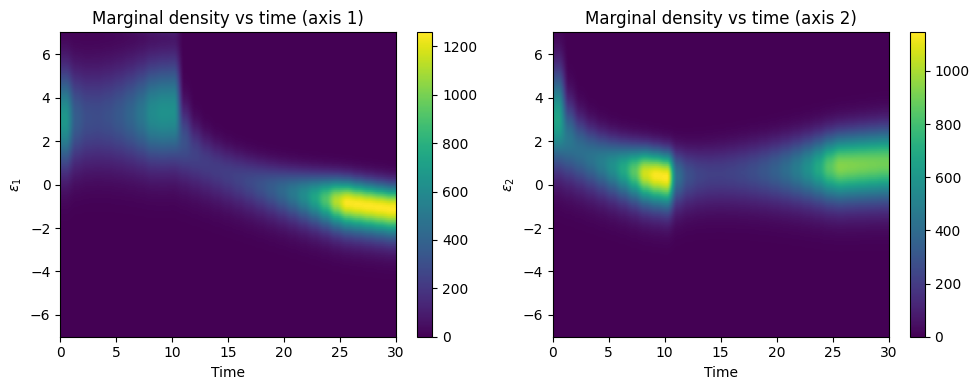

: 

In [ ]:
# run simulation
def get_C(t: float, v: int) -> float:
    """
    Concentrations antigéniques dynamiques.

    Paramètres
    ----------
    t : float
        Temps courant (même unité que dt dans votre simulateur).
    v : int
        Indice de l'antigène (0 ou 1 quand k = 2).

    Retour
    ------
    float
        Concentration C_v(t).
    """
    if t < 10.0:
        return 10.0 if v == 1 else 0.0   # (0, 5)
    else:
        return 10.0 if v == 0 else 0.0   # (5, 0)


eps_axes, times, rho_t = fp_density_time_series_kD(k=2, T=30.0, verbose =True, get_C=get_C)

# Compute marginal densities for each epsilon dimension over time
rho_t_marg1 = rho_t.sum(axis=2) * (eps_axes[1][1]-eps_axes[1][0])  # integrate over eps2
rho_t_marg2 = rho_t.sum(axis=1) * (eps_axes[0][1]-eps_axes[0][0])  # integrate over eps1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
im0 = axes[0].imshow(rho_t_marg1.T, aspect='auto', origin='lower',
                     extent=[times[0], times[-1], eps_axes[0][0], eps_axes[0][-1]])
axes[0].set_xlabel('Time')
axes[0].set_ylabel(r'$\varepsilon_1$')
axes[0].set_title('Marginal density vs time (axis 1)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(rho_t_marg2.T, aspect='auto', origin='lower',
                     extent=[times[0], times[-1], eps_axes[1][0], eps_axes[1][-1]])
axes[1].set_xlabel('Time')
axes[1].set_ylabel(r'$\varepsilon_2$')
axes[1].set_title('Marginal density vs time (axis 2)')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [7]:
def get_C(t: float, v: int) -> float:
    return 2.5
eps_axes, times, rho_t = fp_density_time_series_kD(k=
                                                   2
                                                   
                                                , T=30.0, verbose =True, get_C=get_C)


  10  N=  2475.5  Ω=  0.000  ⟨Γ⟩=  -1.088
  20  N=  2448.7  Ω=  0.000  ⟨Γ⟩=  -1.081
  30  N=  2422.4  Ω=  0.000  ⟨Γ⟩=  -1.074
  40  N=  2396.6  Ω=  0.000  ⟨Γ⟩=  -1.067
  50  N=  2371.2  Ω=  0.000  ⟨Γ⟩=  -1.060
  60  N=  2346.2  Ω=  0.000  ⟨Γ⟩=  -1.054
  70  N=  2321.6  Ω=  0.000  ⟨Γ⟩=  -1.047
  80  N=  2297.4  Ω=  0.000  ⟨Γ⟩=  -1.040
  90  N=  2273.7  Ω=  0.000  ⟨Γ⟩=  -1.034
 100  N=  2250.3  Ω=  0.000  ⟨Γ⟩=  -1.027
 110  N=  2227.3  Ω=  0.000  ⟨Γ⟩=  -1.021
 120  N=  2204.7  Ω=  0.000  ⟨Γ⟩=  -1.014
 130  N=  2182.5  Ω=  0.000  ⟨Γ⟩=  -1.008
 140  N=  2160.6  Ω=  0.000  ⟨Γ⟩=  -1.001
 150  N=  2139.1  Ω=  0.000  ⟨Γ⟩=  -0.995
 160  N=  2117.9  Ω=  0.000  ⟨Γ⟩=  -0.989
 170  N=  2097.1  Ω=  0.000  ⟨Γ⟩=  -0.983
 180  N=  2076.6  Ω=  0.000  ⟨Γ⟩=  -0.976
 190  N=  2056.4  Ω=  0.000  ⟨Γ⟩=  -0.970
 200  N=  2036.6  Ω=  0.000  ⟨Γ⟩=  -0.964
 210  N=  2017.1  Ω=  0.000  ⟨Γ⟩=  -0.958
 220  N=  1997.8  Ω=  0.000  ⟨Γ⟩=  -0.952
 230  N=  1978.9  Ω=  0.000  ⟨Γ⟩=  -0.946
 240  N=  1960.3  Ω=  0.000  ⟨Γ⟩= 

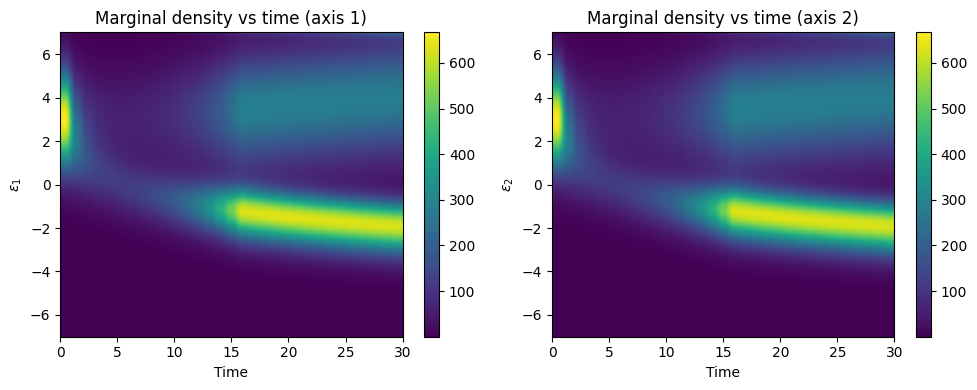

In [8]:
rho_t_marg1 = rho_t.sum(axis=2) * (eps_axes[1][1]-eps_axes[1][0])  # integrate over eps2
rho_t_marg2 = rho_t.sum(axis=1) * (eps_axes[0][1]-eps_axes[0][0])  # integrate over eps1

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
im0 = axes[0].imshow(rho_t_marg1.T, aspect='auto', origin='lower',
                     extent=[times[0], times[-1], eps_axes[0][0], eps_axes[0][-1]])
axes[0].set_xlabel('Time')
axes[0].set_ylabel(r'$\varepsilon_1$')
axes[0].set_title('Marginal density vs time (axis 1)')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(rho_t_marg2.T, aspect='auto', origin='lower',
                     extent=[times[0], times[-1], eps_axes[1][0], eps_axes[1][-1]])
axes[1].set_xlabel('Time')
axes[1].set_ylabel(r'$\varepsilon_2$')
axes[1].set_title('Marginal density vs time (axis 2)')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()